In [2]:
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import ReLU
import scipy.stats as stats
from scipy.interpolate import CubicSpline
from scipy.interpolate import interp1d
from scipy.sparse import diags,spdiags
import matplotlib as mpl
from scipy.interpolate import RegularGridInterpolator
from cvxopt import solvers,matrix

pd.set_option('display.max_columns',6)
pd.set_option('display.max_rows',6)

import matplotlib
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']  # 用于正常显示中文
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

from pfhedge.instruments import BaseInstrument, EuropeanOption
from pfhedge.nn import BlackScholes, EntropicRiskMeasure, ExpectedShortfall, Hedger, MultiLayerPerceptron
from pfhedge.stochastic.local_volatility import generate_local_volatility_process
from pfhedge.instruments.primary.brownian import BrownianStock

In [27]:
class LocalVolatilityStock(BaseInstrument):
    """支持局部波动率的自定义股票类"""
    def __init__(self, cost: float = 0.0, dt: float = 1/250, sigma_fn=None):
        super().__init__()
        self.cost = cost
        self.dt = dt
        self.sigma_fn = sigma_fn
        # 直接作为属性存储，不使用 register_buffer
        self._spot = None
        self._volatility = None
        self._log_spot = None
        
    def to(self, device=None, dtype=None):
        """实现设备转移方法"""
        # 如果有数据，转移到指定设备
        if self._spot is not None:
            self._spot = self._spot.to(device=device, dtype=dtype)
        if self._volatility is not None:
            self._volatility = self._volatility.to(device=device, dtype=dtype)
        if self._log_spot is not None:
            self._log_spot = self._log_spot.to(device=device, dtype=dtype)
        return self
        
    @property
    def spot(self) -> torch.Tensor:
        """返回股价路径"""
        if self._spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._spot
    
    @property
    def log_spot(self) -> torch.Tensor:
        """返回对数股价路径"""
        if self._log_spot is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._log_spot
        
    def is_listed(self, time: float) -> bool:
        """检查股票在给定时间是否上市"""
        return True
        
    def simulate(self, n_paths: int, time_horizon: Optional[float] = None, 
                 init_state: Optional[Tuple[float, ...]] = None):
        """模拟股价路径"""
        if time_horizon is None:
            time_horizon = 30 * self.dt
        
        n_steps = int(time_horizon / self.dt)
        
        # 使用局部波动率模型生成路径
        spot, volatility = generate_local_volatility_process(
            n_paths, n_steps, self.sigma_fn, init_state, self.dt
        )
        
        # 直接存储为属性
        self._spot = spot
        self._volatility = volatility
        self._log_spot = spot.log()
        
        return self

    @property
    def volatility(self):
        """返回波动率路径"""
        if self._volatility is None:
            raise ValueError("Stock not yet simulated. Call simulate() first.")
        return self._volatility

    @property
    def sigma(self):
        """返回波动率（兼容性）"""
        return self.volatility

def create_lv_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma_fn):
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)

    # 只 simulate 一次
    lv_stock = LocalVolatilityStock(
        cost=derivative.underlier.cost,
        dt=derivative.underlier.dt,
        sigma_fn=sigma_fn
    )
    lv_derivative = EuropeanOption(lv_stock, strike=derivative.strike, maturity=derivative.maturity)
    lv_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))

    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs} ...")
        hedger.train()
        pnl = compute_hedge_pnl_for_training(hedger, lv_derivative, features)
        loss_value = loss(pnl)
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        print(f"Loss: {loss_value.item():.6f}")
    hedger.eval()
    return hedger

def compute_hedge_pnl_for_training(hedger, derivative, feature_names):
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    initial_spot = derivative.underlier.spot[:, 0]
    for step in range(n_steps):
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        feature_values = {
            "log_moneyness": (current_spot / derivative.strike).log(),
            "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
            "volatility": current_vol,
            "prev_hedge": current_hedge
        }
        # 只在第一个step打印特征统计
        if step == 0:
            for k, v in feature_values.items():
                print(f"feature {k}: mean={v.mean().item()}, std={v.std().item()}, min={v.min().item()}, max={v.max().item()}")
        input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
        new_hedge = hedger.model(input_features).squeeze()
        if step == 0:
            total_pnl = total_pnl - new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl = total_pnl - hedge_change * current_spot
        current_hedge = new_hedge
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl = total_pnl + current_hedge * final_spot
    total_pnl = total_pnl - option_payoff
    print("final pnl mean:", total_pnl.mean().item(), "std:", total_pnl.std().item(), "min:", total_pnl.min().item(), "max:", total_pnl.max().item())
    return total_pnl

def compute_lv_pnl(hedger, derivative, feature_names, is_black_scholes=False):
    """计算使用局部波动率的对冲策略损益"""
    device = derivative.underlier.spot.device
    n_paths = derivative.underlier.spot.shape[0]
    n_steps = derivative.underlier.spot.shape[1] - 1
    
    # 初始化
    total_pnl = torch.zeros(n_paths, device=device)
    current_hedge = torch.zeros(n_paths, device=device)
    
    # 获取初始股票价格
    initial_spot = derivative.underlier.spot[:, 0]
    
    for step in range(n_steps):
        # 当前时间和股价
        time_to_expiry = derivative.maturity - step * derivative.underlier.dt
        current_spot = derivative.underlier.spot[:, step]
        current_vol = derivative.underlier.volatility[:, step]
        
        if is_black_scholes:
            # Black-Scholes 使用当前的局部波动率
            log_moneyness = (current_spot / derivative.strike).log()
            new_hedge = hedger.delta(log_moneyness, time_to_expiry, current_vol)
        else:
            # 神经网络：使用真实的局部波动率作为输入
            feature_values = {
                "log_moneyness": (current_spot / derivative.strike).log(),
                "expiry_time": torch.full((n_paths,), time_to_expiry, device=device),
                "volatility": current_vol,
                "prev_hedge": current_hedge
            }
            # 构建输入
            input_features = torch.stack([feature_values[name] for name in feature_names], dim=1)
            new_hedge = hedger.model(input_features).squeeze()
        
        # 计算对冲成本
        if step == 0:
            total_pnl -= new_hedge * initial_spot
        else:
            hedge_change = new_hedge - current_hedge
            total_pnl -= hedge_change * current_spot
        
        current_hedge = new_hedge
    
    # 最终清算
    final_spot = derivative.underlier.spot[:, -1]
    option_payoff = (final_spot - derivative.strike).clamp(min=0)
    total_pnl += current_hedge * final_spot
    total_pnl -= option_payoff
    
    return total_pnl

def create_gbm_hedger(loss, derivative, features, n_epochs, n_paths, init_spot, sigma):
    model = MultiLayerPerceptron(n_layers=4, n_units=[64, 32, 32, 16], activation=ReLU())
    hedger = Hedger(model, features, criterion=loss)
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.001)
    for epoch in range(n_epochs):
        # 创建新的GBM股票
        gbm_stock = BrownianStock(cost=derivative.underlier.cost, dt=derivative.underlier.dt, sigma=sigma)
        gbm_derivative = EuropeanOption(gbm_stock, strike=derivative.strike, maturity=derivative.maturity)
        gbm_derivative.simulate(n_paths=n_paths, init_state=(init_spot,))
        hedger.train()
        pnl = compute_hedge_pnl_for_training(hedger, gbm_derivative, features)
        loss_value = loss(pnl)
        optimizer.zero_grad()
        loss_value.backward()
        optimizer.step()
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch + 1}/{n_epochs}, Loss: {loss_value.item():.6f}")
    hedger.eval()
    return hedger

data_raw = pd.read_pickle(r"C:/Users/jimmy/Documents/workspace1/pfhedge-ty/stats/sse50_option_data_processed_20231110.pkl")

parity_data = data_raw.loc[data_raw["实虚值"] == "虚值"].copy()
parity_data["parity_call_price"] = np.where(parity_data["CP"] == 0,parity_data["close"],parity_data["close"] + np.exp(-parity_data["r"]*parity_data["maturity"]) * (parity_data["F"]-parity_data["exerciseprice"]))
parity_data = parity_data.sort_values(["contract_month","CP","exerciseprice"])
parity_data

parity_data["w"] = parity_data["market_imp_vol"]**2 * parity_data["maturity"]  #计算总方差
parity_data["y"] = np.log(parity_data["exerciseprice"]/parity_data["F"])  #计算远期在值程度

class cons_smoothing_spline:
    def __init__(self,x,y,w,lamda,S,r,q,T,prev_spline = None,solve_order = "forward"):
        self.x = np.array(x)  #n个点的x值
        self.y = np.array(y)  #n个点的y值
        self.h = self.x[1:] - self.x[:-1]  #n-1个值
        self.w = w  #最优化时候的权重,n维度
        self.lamda = lamda #光滑系数，越大代表曲线越光滑
        self.S = S  #标的价格
        self.r = r  #无风险利率
        self.q = q  # 股利率
        self.T = T  #到期时间
        self.prev_spline = prev_spline  #上一次迭代的样条平滑的实例，如果是第一次迭代那么就是None
        self.solve_order = solve_order  #forwrd代表从最近月开始求解，backward代表从最远月开始求解
        self.dim = len(x)  #记录一下x的维度，后续都需要使用到
    def gen_coef(self):
        #生成目标函数的系数矩阵yT和B

        R = 1/6 * diags(diagonals = [self.h[1:],2*(self.h[:-1]+self.h[1:]),self.h[1:]], 
                   offsets= [-1,0,1],shape=(self.dim-2,self.dim-2) ).toarray()
        #-----------------------------
        #生成B
        B = np.zeros((2*self.dim-2,2*self.dim-2))
        B[:self.dim,:self.dim] = np.eye(self.dim)*self.w
        B[self.dim:,self.dim:] = self.lamda * R
        #-----------------------------
        #生成yT
        yT = np.zeros(2*self.dim - 2) # 2n-2维度
        yT[0:self.dim] = self.w * self.y  

        return yT,B

    def gen_eq_cons(self):

        #生成等式约束A
        h_inverse = 1/self.h
        QT = diags(diagonals = [h_inverse[:-1],-(h_inverse[:-1]+h_inverse[1:]),h_inverse[1:]],  
                   offsets= [0,1,2],shape=(self.dim-2,self.dim) ).toarray()
        R = 1/6 * diags(diagonals = [self.h[1:],2*(self.h[:-1]+self.h[1:]),self.h[1:]], 
                   offsets= [-1,0,1],shape=(self.dim-2,self.dim-2) ).toarray()
        AT = np.hstack([QT,-R])
        return AT

    def gen_ineq_cons1(self):
        """
        为了逻辑清晰，先生成除了*号（4）的约束
        """
        #-----------------------------    
        #生成不等式约束左边：G     
        G = np.zeros((4+self.dim-2,2*self.dim-2))  # self.dim-2个gamma的条件，4个其他条件，2*self.dim-2个变量。

        # cons_2
        G[0,0] = 1/self.h[0]
        G[0,1] = -1/self.h[0]
        G[0,self.dim] = self.h[0]/6
        # cons_3
        G[1,self.dim-2] = -1/self.h[-1]
        G[1,self.dim-1] = 1/self.h[-1]
        G[1,-1] = self.h[-1]/6 
        # cons_5
        G[2,0] = -1
        # cons_6
        G[3,self.dim-1] = -1  

        # cons_1,这个cons1比较复杂，所以写在最下面

        G[4:,self.dim:] = -np.eye(self.dim-2)  #对角线为-1的self.dim-2维度

        #-----------------------------
        #生成不等式约束右边： h_ieq(h_ieq为不等式的右边)  
        h_ieq = np.zeros((4+self.dim-2,1))

        h_ieq[0] = np.exp(-self.r*self.T)
        h_ieq[2] =  np.exp(-self.r*self.T)*self.x[0] - np.exp(-self.q*self.T)*self.S

        return G,h_ieq  

    def gen_ineq_cons2(self):
        """
        因为*号的条件再往前推的时候会变化，所以这里单独写
        """
        prev_spline = self.prev_spline
        #-----------------------------   
        if prev_spline:  #若不是第一次迭代，需要指定上一次迭代的样条实例
            #生成不等式约束左边：G 
            G = np.zeros((self.dim,2*self.dim-2))  # n个不等式约束
            h_ieq = np.zeros((self.dim,1))     
            
            #生成不等式约束右边： h_ieq(h_ieq为不等式的右边) ,if判断正向和反向求解的顺序
            if self.solve_order == "forward":
                G[:,:self.dim] = - np.eye(self.dim)
                prev_x = np.exp((self.r-self.q)*self.T)/np.exp((prev_spline.r-prev_spline.q)*prev_spline.T)*self.x#根据当前的行权价格x，和远期在值程度条件，计算对应的上一期行权价格x
                h_ieq[:,0] = - np.exp(self.q*self.T-prev_spline.q*prev_spline.T) * prev_spline.eval(prev_x)           
        
            else:
                G[:,:self.dim] = np.eye(self.dim)
                prev_x = np.exp((prev_spline.r-prev_spline.q)*prev_spline.T)/np.exp((self.r-self.q)*self.T)*self.x#根据当前的行权价格x，和远期在值程度条件，计算对应的上一期行权价格x
                h_ieq[:,0] = np.exp(prev_spline.q*prev_spline.T-self.q*self.T) * prev_spline.eval(prev_x)           

        else:   #第一次迭代，则prev_spline为None,不等式约束较为简单

            #生成不等式约束左边：G 
            G = np.zeros((1,2*self.dim-2))  # 1个不等式约束
            G[0,0] = 1 

            #生成不等式约束右边： h_ieq(h_ieq为不等式的右边) 

            h_ieq = np.zeros((1,1))
            h_ieq[0,0] = np.exp(-self.q*self.T)*self.S

        return G,h_ieq



    def gen_ineq_cons(self):
        # 合并上面的两个不等式约束
        G_1,h_ieq_1 = self.gen_ineq_cons1()
        G_2,h_ieq_2 = self.gen_ineq_cons2()
        G = np.vstack((G_1,G_2))
        h_ieq = np.vstack((h_ieq_1,h_ieq_2))
        return G,h_ieq


    def solve_g_gamma(self):

        #利用cvxopt解二次规划问题，求得g_m
        yT,B = self.gen_coef()
        AT = self.gen_eq_cons()
        G,h_ieq = self.gen_ineq_cons()
        yT,AT,B,G,h_ieq = matrix(yT,tc="d"),matrix(AT,tc="d"),matrix(B,tc="d"),matrix(G,tc="d"),matrix(h_ieq,tc="d")
        b = matrix(np.zeros(self.dim-2),tc="d")

        g_gamma = solvers.qp(P = B,q = -yT,G = G,h = h_ieq,A = AT,b = b)["x"]  #这里求出了x，里面包括样本点的n个拟合函数的值和n-2个二阶导数值
        g_gamma = np.array(g_gamma).reshape(2*self.dim-2,)  #这里reshape一下，array里（n,1）和（n,）是不一样的

        g = g_gamma[:self.dim] #前n个是样本点的拟合函数的值
        gamma = np.zeros_like(g) 
        gamma[1:-1] = g_gamma[self.dim:] ##后n-2个是样本点的二阶导数值
        self.g = g
        self.gamma = gamma
        return g,gamma


    def fit(self):
        #求得g,gamma后，还需要还原实际的ai，bi，ci，di的系数
        g,gamma = self.solve_g_gamma()

        ai = g[:-1]
        bi = (g[1:]-g[:-1])/self.h - self.h/6*(2*gamma[:-1]+gamma[1:])
        ci = gamma[:-1]/2
        di = (gamma[1:] - gamma[:-1])/(6*self.h)
        coef = np.array([ai,bi,ci,di])
        self.coef = coef


    def eval(self,xn):
        yn = np.zeros(len(xn))
        for i in range(len(xn)):
            if xn[i] <= self.x[0]: #支持外插，比样本点的最小值还小时的处理
                a,b = self.coef[:2,0]  # a0=a1,b0=b1
                yn[i] = a + b*(xn[i]-self.x[0])

            elif xn[i] >= self.x[-1]: #支持外插，比样本点的最大值还大时的处理
                a = self.g[-1] #an = gn
                b = (self.g[-1]-self.g[-2])/self.h[-1] + self.h[-1]/6*(2*self.gamma[-1]+self.gamma[-2])
                yn[i] = a + b*(xn[i]-self.x[-1])
            else:
                xn_idx = np.where(self.x<=xn[i])[0][-1]  #np.where只有condition时会返回符合条件的索引，不过返回的是2维的元组，[0]获取索引列表
                a,b,c,d = self.coef[:,xn_idx]
                yn[i] = a + b*(xn[i]-self.x[xn_idx]) + c*(xn[i]-self.x[xn_idx])**2 + d*(xn[i]-self.x[xn_idx])**3 
        return yn

In [4]:
test = parity_data.loc[data_raw["contract_month"]=="2311"].sort_values("exerciseprice")
x = test["exerciseprice"]
y = test["parity_call_price"]
S = test["S0"].unique()[0]
r = test["r"].unique()[0]
q = test["q"].unique()[0]
T = test["maturity"].unique()[0]

spline = cons_smoothing_spline(x,y,1,0.00001,S,r,q,T)  
spline.fit()

     pcost       dcost       gap    pres   dres
 0:  1.0522e-01 -5.8942e+00  6e+00  1e-12  1e+02
 1:  5.5569e-02 -4.5212e-01  5e-01  2e-13  1e+01
 2: -2.6966e-02 -6.6002e-02  4e-02  1e-13  2e-01
 3: -3.3774e-02 -5.5935e-02  2e-02  7e-14  1e-01
 4: -3.9165e-02 -6.1854e-02  2e-02  7e-14  1e-01
 5: -6.3891e-02 -9.3424e-02  3e-02  6e-14  3e-02
 6: -6.4406e-02 -6.6472e-02  2e-03  1e-14  1e-03
 7: -6.4519e-02 -6.4765e-02  2e-04  2e-15  5e-05
 8: -6.4548e-02 -6.4632e-02  8e-05  8e-16  8e-06
 9: -6.4558e-02 -6.4574e-02  2e-05  1e-15  6e-07
10: -6.4559e-02 -6.4560e-02  1e-06  1e-15  1e-08
11: -6.4559e-02 -6.4559e-02  1e-07  8e-16  1e-09
12: -6.4559e-02 -6.4559e-02  1e-08  1e-15  1e-11
Optimal solution found.


2311
     pcost       dcost       gap    pres   dres
 0:  1.0522e-01 -5.8942e+00  6e+00  1e-12  1e+02
 1:  5.5569e-02 -4.5212e-01  5e-01  2e-13  1e+01
 2: -2.6966e-02 -6.6002e-02  4e-02  1e-13  2e-01
 3: -3.3774e-02 -5.5935e-02  2e-02  7e-14  1e-01
 4: -3.9165e-02 -6.1854e-02  2e-02  7e-14  1e-01
 5: -6.3891e-02 -9.3424e-02  3e-02  6e-14  3e-02
 6: -6.4406e-02 -6.6472e-02  2e-03  1e-14  1e-03
 7: -6.4519e-02 -6.4765e-02  2e-04  2e-15  5e-05
 8: -6.4548e-02 -6.4632e-02  8e-05  8e-16  8e-06
 9: -6.4558e-02 -6.4574e-02  2e-05  1e-15  6e-07
10: -6.4559e-02 -6.4560e-02  1e-06  1e-15  1e-08
11: -6.4559e-02 -6.4559e-02  1e-07  8e-16  1e-09
12: -6.4559e-02 -6.4559e-02  1e-08  1e-15  1e-11
Optimal solution found.
2312
     pcost       dcost       gap    pres   dres
 0: -6.5907e-02 -1.6905e+00  5e+01  6e+00  6e+01
 1:  1.8942e+00 -2.9302e+00  5e+00  1e-12  8e-14
 2:  2.2467e-01 -4.4950e-01  7e-01  7e-13  5e-13
 3:  4.7690e-02 -2.7531e-01  3e-01  3e-13  2e-13
 4: -6.1581e-02 -1.0823e-01  5e-02  5

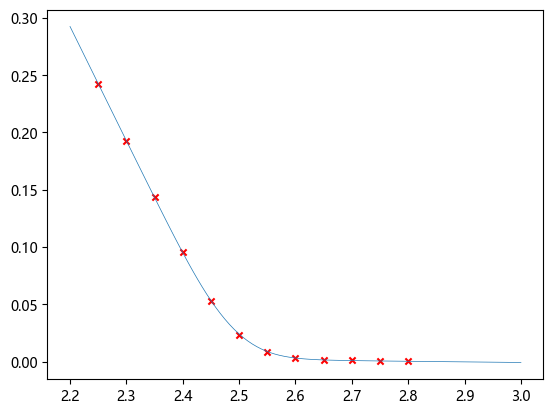

In [5]:
x_test = np.linspace(2.2,3,100)
y_test = spline.eval(x_test)
plt.scatter(x,y,s=20,marker="x",c = "r")
plt.plot(x_test,y_test,linewidth = 0.5)

def get_spline(data):
    """
    用来获取所有拟合月份的样条函数列表

    """
    spline_list = []
    contract_month = data["contract_month"].unique()
    for i,t in enumerate(contract_month):   #从最近月开始拟合
        print(t)
        test = data.loc[(data["contract_month"]== t)].sort_values("exerciseprice")
        x = test["exerciseprice"]
        y = test["parity_call_price"]
        S = test["S0"].unique()[0]
        r = test["r"].unique()[0]
        q = test["q"].unique()[0]
        T = test["maturity"].unique()[0]
        if i == 0:  #对于第一次循环，拟合的是最近月，spline不需要prev
            spline = cons_smoothing_spline(x,y,1,0.00001,S,r,q,T)
        else:  #如果不是第一次循环，那么需要上一次的样条进行日历套利的约束
            spline = cons_smoothing_spline(x,y,1,0.00001,S,r,q,T,spline_list[-1]) #spline_list[-1]表示上一次的样条
        spline.fit()
        spline_list.append(spline)
    return spline_list
spline_list = get_spline(parity_data)

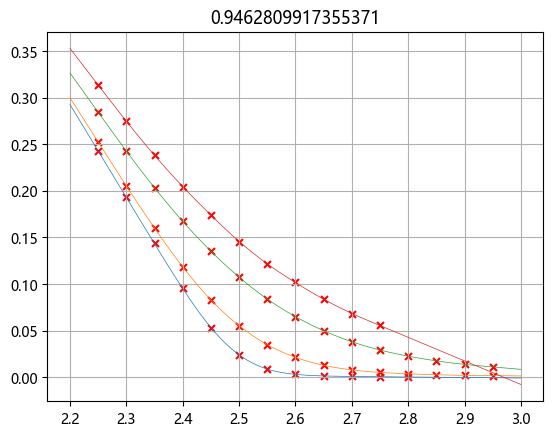

In [6]:
for spl in spline_list:
    test = parity_data.loc[parity_data["maturity"]== spl.T]
    x = test["exerciseprice"]
    y = test["parity_call_price"]
    x_test = np.linspace(2.2,3,100)
    y_test = spl.eval(x_test)
    plt.scatter(x,y,s=25,marker="x",c = "r")
    plt.plot(x_test,y_test,linewidth = 0.5)
    plt.grid("y")
    plt.title(spl.T)

In [19]:
from numpy import exp  #直接导入exp，省的每次都要写np.exp
from scipy.stats import norm #直接导入norm，省的每次都要写stats.norm

def BSM(CP,S,X,sigma,T,r,b):
    d1 = (np.log(S/X) + (b + sigma**2/2)*T) / (sigma* np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = S * exp((b - r)*T) *norm.cdf(d1) - X * exp(-r*T) * norm.cdf(d2)
    put_price =  X * exp(-r*T) * norm.cdf(-d2) - S * exp((b - r)*T) * norm.cdf(-d1)
    value = call_price + CP*(put_price-call_price)
    return value

def newton_imp_vol(C0, CP, S, X, T, r, b, vol_est=0.25, n_iter=100):
    for i in range(n_iter):
        if vol_est < 1e-6 or vol_est > 5:
            return np.nan
        d1 = (np.log(S/X) + (b + vol_est**2/2)*T) / (vol_est* np.sqrt(T))
        vega = S * np.exp((b-r)*T) * norm.pdf(d1) * T**0.5
        price = BSM(CP, S, X, vol_est, T, r, b)
        # 新增保护
        if vega == 0 or np.isnan(vega) or np.isinf(vega) or abs(vega) < 1e-8:
            return np.nan
        if abs((price - C0) / vega) < 0.0001:
            break
        step = (price - C0) / vega
        # 防止 step 溢出
        if abs(step) > 10:
            return np.nan
        vol_est = vol_est - step
    if np.isnan(vol_est) or np.isinf(vol_est) or vol_est < 1e-6 or vol_est > 5:
        return np.nan
    return vol_est

def get_total_v(data,spline_list,y,t,output="sigma_2_T"):
    """
    output控制输出的类型为隐含波动率（sigma），或总方差（sigma_2_T）
    """
    strike = np.exp(y)*data["F"].unique()  # 将在值程度转化为行权价格，方便用平滑样条计算对应的价值
    vol_array = np.zeros(len(spline_list))
    for i in range(len(spline_list)):
        smoothed_price = spline_list[i].eval([strike[i]])
        imp_vol = newton_imp_vol(smoothed_price,0,spline_list[i].S,strike[i],spline_list[i].T,spline_list[i].r,spline_list[i].r-spline_list[i].q)
        vol_array[i] = (imp_vol**2 * spline_list[i].T).item()  # 明确提取标量值

    f = interp1d(x =data["maturity"].unique(),y = vol_array,kind = "linear",fill_value="extrapolate")
    v = float(f(t))
    if output == "sigma":  #若output为sigma,那么就把总方差转化为波动率。
        v = np.sqrt(v/t)
    return v
get_total_v(parity_data,spline_list,0.12,0.2,"sigma")

0.15759525293122356

In [8]:
def get_imp_vol(data,spline_list):
    t_array = np.linspace(data["maturity"].min(),data["maturity"].max(),20)
    y_array = np.linspace(-0.1,0.12,30)   # 减少外插样本
    t, y = np.meshgrid(t_array,y_array) 
    v = np.zeros_like(y)

    # 循环确定每个点的隐含波动率，上一步已经存储了k维度上的样条函数，循环的时候还需要t维度的样条插值，这样可以计算任意点的隐含波动率值
    for t_idx,t1 in enumerate(t_array):
        for y_idx,y1 in enumerate(y_array):
            v[y_idx,t_idx] = get_total_v(data,spline_list,y1,t1,output="sigma")
    return t,y,v
# 根据3维数据生成曲面图像
def plot_ivs(t,k,v):
    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection='3d')
    norm = mpl.colors.Normalize(vmin=0.1, vmax=0.2)
    # 绘图主程序
    surf = ax.plot_surface(t, k, v, rstride=1, cstride=1,
    cmap=plt.cm.coolwarm,norm = norm,linewidth=0.5, antialiased=True)
    # 设置坐标轴
    ax.set_xlabel('maturity')
    ax.set_ylabel('strike')
    ax.set_zlabel('market_imp_vol')
    ax.set_zlim((0.1,0.2))
    fig.colorbar(surf, shrink=0.25, aspect=5)
t,y,v = get_imp_vol(parity_data,spline_list)

def diff(data,spline,y,t):
    yt = get_total_v(data,spline,y,t)
    y_up = get_total_v(data,spline,y*(1+0.001),t)
    y_down = get_total_v(data,spline,y*(1-0.001),t)
    t_up = get_total_v(data,spline,y,t*(1+0.001))

    dw_dt = (t_up - yt)/(t*0.001)
    dw_dy = (y_up - y_down)/(y*0.001*2)
    dw_dy2 = (y_up + y_down - 2*yt)/(y*0.001)**2
    return dw_dt,dw_dy,dw_dy2

def local_v(data, spline_list, y, t):
    w = get_total_v(data, spline_list, y, t, "sigma_2_T")
    # 防止w过小导致溢出
    if w < 1e-6:
        w = 1e-6
    dw_dt, dw_dy, dw_dy2 = diff(data, spline_list, y, t)
    numetator = dw_dt
    denonimator = 1 - y / w * dw_dy + 0.25 * (-0.25 - 1 / w + y ** 2 / w ** 2) * (dw_dy ** 2) + 0.5 * dw_dy2
    # 防止分母过小
    if abs(denonimator) < 1e-8:
        denonimator = 1e-8 if denonimator >= 0 else -1e-8
    local_variance = numetator / denonimator
    if local_variance < 0:
        local_variance = 1e-8
    return np.sqrt(local_variance)

def get_local_variance(data,spline_list):
    t_array = np.linspace(0.05,0.92,20)    # 减少到期边缘的影响
    y_array = np.linspace(-0.10,0.12,20)   # 减少外插样本
    t, y = np.meshgrid(t_array,y_array) 
    v = np.zeros_like(y)

    # 循环确定每个点的隐含波动率，上一步已经存储了k维度上的样条函数，循环的时候还需要t维度的样条插值，这样可以计算任意点的隐含波动率值
    for t_idx,t1 in enumerate(t_array):
        for y_idx,y1 in enumerate(y_array):
            v[y_idx,t_idx] = local_v(data,spline_list,y1,t1)
    return t,y,v
# 根据3维数据生成曲面图像
def plot_ivs(t,k,v):
    fig = plt.figure(figsize=(12, 7))
    ax = plt.axes(projection='3d')
    norm = mpl.colors.Normalize(vmin=0, vmax=0.5)
    # 绘图主程序
    surf = ax.plot_surface(t, k, v, rstride=1, cstride=1,
    cmap=plt.cm.coolwarm,norm = norm,linewidth=0.5, antialiased=True)
    # 设置坐标轴
    ax.set_xlabel('maturity')
    ax.set_ylabel('strike')
    ax.set_zlabel('local_vol')
    ax.set_zlim((0,0.5))
    fig.colorbar(surf, shrink=0.25, aspect=5)
t,y,v = get_local_variance(parity_data,spline_list)

生成局部波动率曲面可视化...


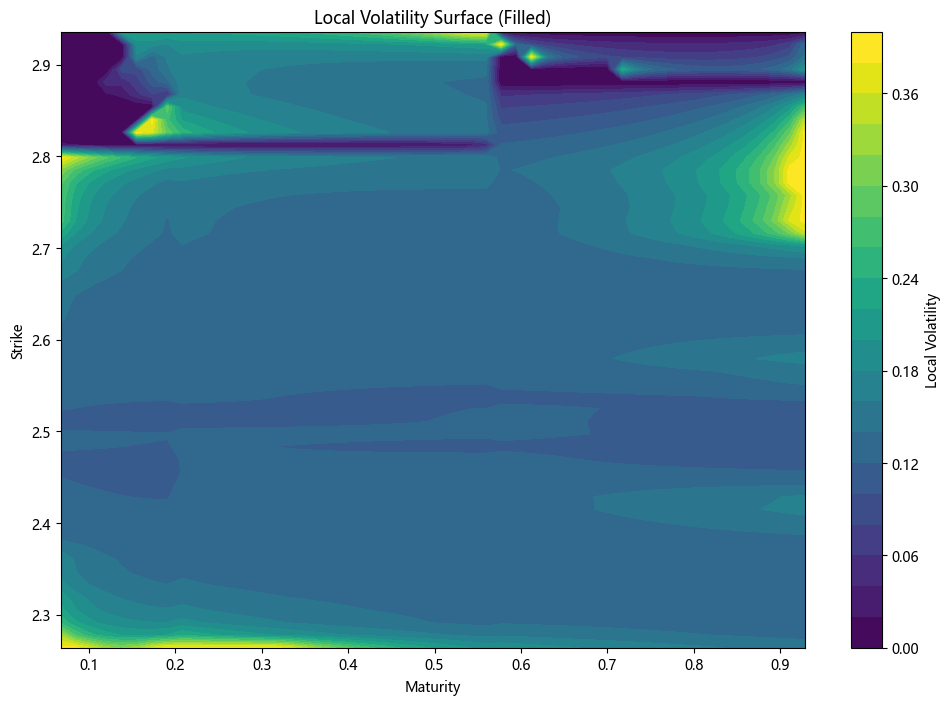

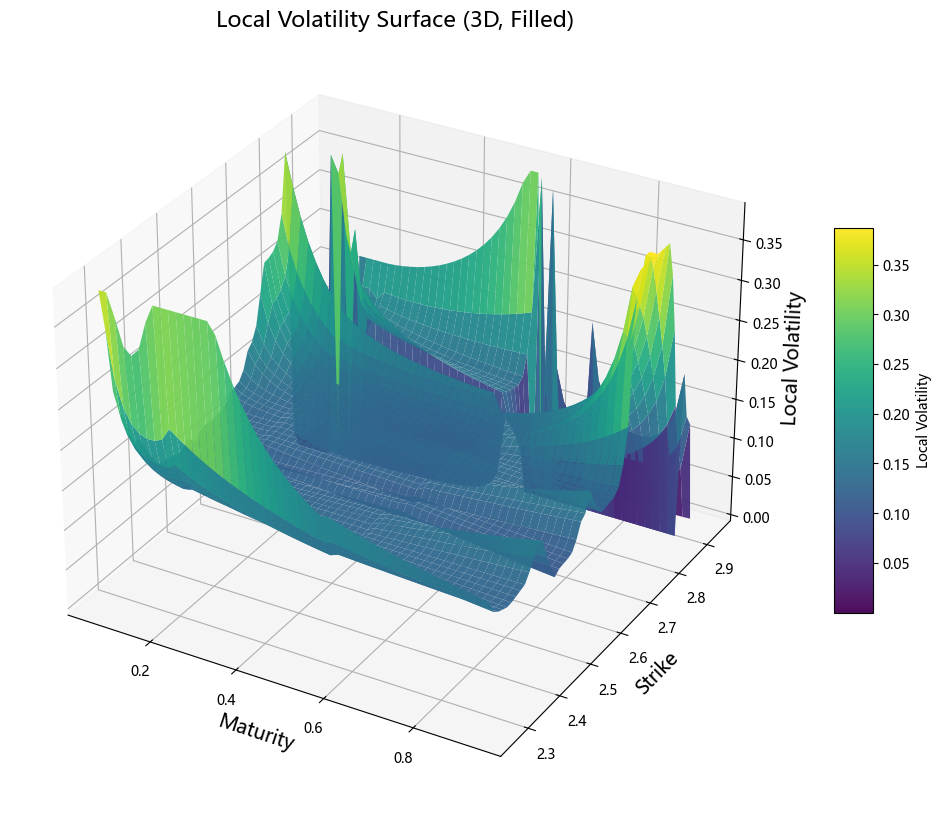

In [16]:
# 设置参数
n_training_paths = 1000  # 减少路径数以加快调试
n_time_steps = 30
time_step = 1 / 250
initial_price = 3.0
initial_state = (initial_price,)

print("生成局部波动率曲面可视化...")

# 只在有效区间插值，并收缩 meshgrid 区间，避免边界外推
strike_min, strike_max = parity_data['exerciseprice'].min(), parity_data['exerciseprice'].max()
maturity_min, maturity_max = parity_data['maturity'].min(), parity_data['maturity'].max()
buffer_s = (strike_max - strike_min) * 0.02
buffer_t = (maturity_max - maturity_min) * 0.02
strike_range = np.linspace(strike_min + buffer_s, strike_max - buffer_s, 50)
maturity_range = np.linspace(maturity_min + buffer_t, maturity_max - buffer_t, 50)
strike_grid, maturity_grid = np.meshgrid(strike_range, maturity_range, indexing='ij')

F = parity_data['F'].mean()
y_grid = np.log(strike_grid / F)

vol_surface = np.full_like(strike_grid, np.nan)
for i in range(strike_grid.shape[0]):
    for j in range(strike_grid.shape[1]):
        y = y_grid[i, j]
        t = maturity_grid[i, j]
        try:
            v = local_v(parity_data, spline_list, y, t)
            if np.isnan(v) or np.isinf(v):
                v = np.nan
        except Exception:
            v = np.nan
        vol_surface[i, j] = v

from scipy.interpolate import griddata

# 1. 获取所有有效点的坐标和值
points = np.array([
    (strike_grid[i, j], maturity_grid[i, j])
    for i in range(strike_grid.shape[0])
    for j in range(strike_grid.shape[1])
    if not np.isnan(vol_surface[i, j])
])
values = np.array([
    vol_surface[i, j]
    for i in range(strike_grid.shape[0])
    for j in range(strike_grid.shape[1])
    if not np.isnan(vol_surface[i, j])
])

# 2. 对所有点进行插值（包括原本为 nan 的点）
grid_points = np.stack([strike_grid.ravel(), maturity_grid.ravel()], axis=-1)
# 先用 cubic/linear 插值
filled_surface = griddata(points, values, grid_points, method='cubic')
filled_surface = filled_surface.reshape(strike_grid.shape)

# 对 nan 区域再用最近邻插值补全
filled_surface_nn = griddata(points, values, grid_points, method='nearest')
filled_surface_nn = filled_surface_nn.reshape(strike_grid.shape)

# 用最近邻结果填补 cubic/linear 的 nan 区域
vol_surface_filled = np.where(np.isnan(filled_surface), filled_surface_nn, filled_surface)

# vmin/vmax 只对有效值计算
vmin, vmax = np.nanpercentile(vol_surface_filled, [1, 99])
Z_plot = np.clip(vol_surface_filled, vmin, vmax)

# 2D contourf
plt.figure(figsize=(12, 8))
contour = plt.contourf(
    maturity_range, strike_range, Z_plot,
    levels=20, cmap='viridis', vmin=vmin, vmax=vmax
)
plt.colorbar(contour, label='Local Volatility')
plt.xlabel('Maturity')
plt.ylabel('Strike')
plt.title('Local Volatility Surface (Filled)')
plt.show()

# 3D surface
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(
    maturity_grid, strike_grid, Z_plot,
    cmap='viridis', edgecolor='none', alpha=0.95
)
ax.set_xlabel('Maturity', fontsize=14)
ax.set_ylabel('Strike', fontsize=14)
ax.set_zlabel('Local Volatility', fontsize=14)
ax.set_title('Local Volatility Surface (3D, Filled)', fontsize=16)
fig.colorbar(surf, shrink=0.5, aspect=10, label='Local Volatility')
plt.show()